# Proyecto Customer Churn

## Laboratorio de Minería de Datos

### Objetivo

Realizar un análisis exploratorio del dataset histórico de Customer Churn
y preparar los datos para posteriormente construir y evaluar modelos de
Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/customer_churn_historical.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6684-LWVH,Male,0,No,No,4,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47,No
1,7027-JIFO,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47,No
2,5981-VOQO,Female,0,No,No,45,Yes,Yes,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35,No
3,7266-HYDM,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96,Yes
4,2821-JDLS,Female,0,Yes,No,5,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12,No


In [6]:
print("Filas y columnas:", df.shape)

df.info()

Filas y columnas: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,1398-XMGM,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.170098,0.375746,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,35.168394,18.901478,0.0,20.0,35.0,51.0,72.0
PhoneService,7043,2,Yes,6368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3203,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Comprensión inicial de los datos

Antes de realizar transformaciones o entrenar modelos, se revisan las
variables disponibles, sus tipos de datos y su función dentro del problema
de clasificación

In [8]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [9]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [10]:
resumen = pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isnull().sum(),
    "unicos": df.nunique()
})

resumen

,tipo,nulos,unicos
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


### Observaciones iniciales

- El dataset contiene 7.043 observaciones y 21 variables.
- `customerID` funciona como identificador único, y no será utilizado como
  variable predictiva.
- La mayoría de las variables son categóricas
- `tenure`, `MonthlyCharges` y `TotalCharges` representan variables numéricas.
- `SeniorCitizen` está codificada numéricamente como una variable binaria.
- `TotalCharges` presenta 26 valores faltantes. Éstos no se imputan
  durante el EDA, ya que su tratamiento se realizará posteriormente dentro
  del pipeline de preprocesamiento
- La variable objetivo es `Churn`, con dos categorías

In [11]:
df["Churn"].value_counts()

,count
Churn,
No,5186
Yes,1857


In [12]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.633395
Yes,26.366605


### Distribución de la variable objetivo

La variable objetivo `Churn` presenta una distribución desigual:

- No: 5.186 observaciones (73,63 %)
- Yes: 1.857 observaciones (26,37 %)

La clase mayoritaria corresponde a clientes que no abandonaron el servicio.
Esta distribución deberá tenerse en cuenta posteriormente al evaluar los
modelos, evitando depender únicamente de la métrica de accuracy.

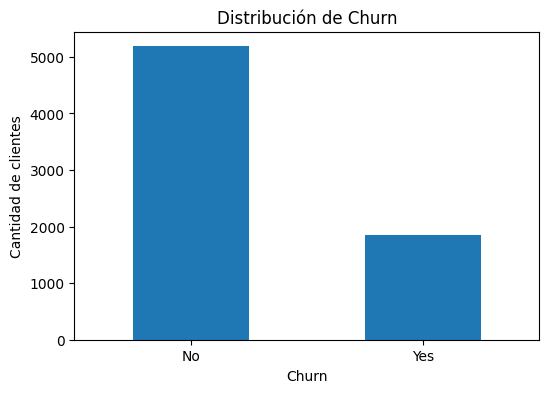

In [13]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
churn_counts.plot(kind="bar")

plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

plt.show()

## 2. Análisis exploratorio de variables

### Tipo de contrato y Churn

Se analiza la relación entre el tipo de contrato del cliente y la variable
objetivo `Churn`.

In [14]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2335,1476
One year,1289,227
Two year,1562,154


In [15]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,61.270008,38.729992
One year,85.026385,14.973615
Two year,91.025641,8.974359


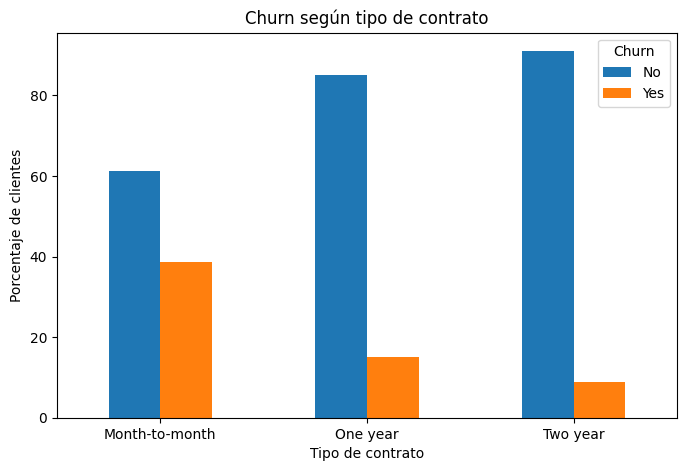

In [16]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Porcentaje de clientes")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

### Observación

Se observa una relación entre el tipo de contrato y la proporción de Churn.

Los clientes con contratos mes a mes presentan una proporción de abandono
considerablemente mayor que aquellos con contratos de uno o dos años.
A medida que aumenta la duración del contrato, disminuye la proporción
observada de clientes que abandonan el servicio.

Esta relación es descriptiva y no implica necesariamente causalidad.


In [17]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5186.0,37.278249,18.711882,0.0,22.0,38.0,53.0,72.0
Yes,1857.0,29.276252,18.171585,0.0,14.0,27.0,43.0,72.0


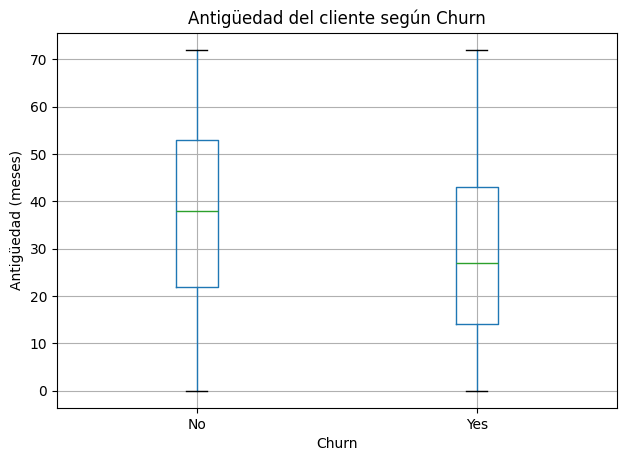

In [18]:
df.boxplot(
    column="tenure",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Antigüedad del cliente según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Antigüedad (meses)")

plt.show()

### Observación

Los clientes que presentan Churn muestran, en promedio, una menor antigüedad
que aquellos que permanecen en el servicio.

La antigüedad media es de aproximadamente 29 meses para los clientes con
Churn y de 37 meses para los clientes sin Churn. Las medianas son de
27 y 38 meses, respectivamente.

Esto sugiere una asociación entre una menor antigüedad del cliente y una
mayor presencia de Churn, sin implicar una relación causal.

### Servicio de Internet y Churn

Se analiza la proporción de Churn según el tipo de servicio de Internet
contratado por el cliente.


In [20]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,80.034350,19.965650
Fiber optic,59.747235,40.252765
No,92.382182,7.617818


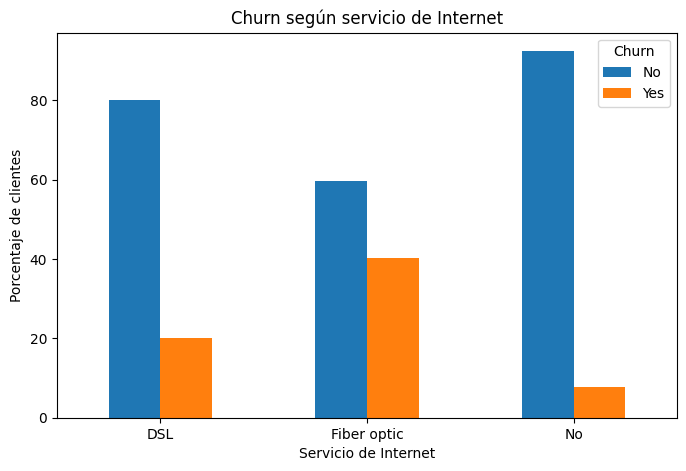

In [21]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn según servicio de Internet")
plt.xlabel("Servicio de Internet")
plt.ylabel("Porcentaje de clientes")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

### Observación

La proporción de Churn varía según el tipo de servicio de Internet.

Los clientes con servicio de fibra óptica presentan la mayor proporción de
Churn, cercana al 40 %. En los clientes con DSL la proporción es
considerablemente menor, mientras que quienes no poseen servicio de Internet
presentan la menor proporción de abandono.

Esto sugiere una asociación entre el tipo de servicio de Internet y Churn,
sin implicar una relación causal.

In [23]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5186.0,63.940046,25.666951,18.0,33.84,69.305,84.86,114.41
Yes,1857.0,79.977216,18.378920,18.0,71.73,84.690,92.14,114.16


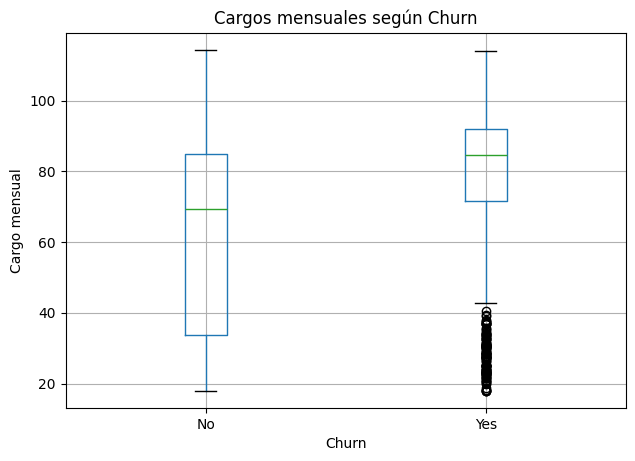

In [24]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Cargos mensuales según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")

plt.show()

### Observación

Los clientes que presentan Churn muestran cargos mensuales más altos que
aquellos que permanecen en el servicio.

El cargo mensual medio es de aproximadamente 80 para los clientes con Churn
y de 64 para los clientes sin Churn. Las medianas son aproximadamente
84,7 y 69,3, respectivamente.

Esto sugiere una asociación entre cargos mensuales más altos y una mayor
presencia de Churn, sin implicar una relación causal.

In [25]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if col != "customerID":
        print(f"\n{col}:")
        print(df[col].value_counts())


gender:
gender
Male      3560
Female    3483
Name: count, dtype: int64

Partner:
Partner
No     3623
Yes    3420
Name: count, dtype: int64

Dependents:
Dependents
No     4954
Yes    2089
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6368
No      675
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3456
Yes                 2912
No phone service     675
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3165
DSL            2329
No             1549
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3203
Yes                    2291
No internet service    1549
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3062
Yes                    2432
No internet service    1549
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No                     3019
Yes                    2475
No internet service    1549
Name: count, dtype: int64

TechSupport:
TechSupport
No   

### Revisión de variables categóricas

Las variables categóricas presentan valores consistentes y no se observan
categorías aparentemente erróneas o duplicadas por diferencias de escritura.

Algunas variables incluyen categorías como `No phone service` o
`No internet service`, que representan la ausencia del servicio
correspondiente y deben conservarse como categorías válidas.

Estas variables requerirán posteriormente una transformación adecuada para
poder ser utilizadas por los modelos de Machine Learning.

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df["customerID"].duplicated().sum()

np.int64(0)

### Duplicados

No se encontraron registros completamente duplicados ni identificadores
`customerID` repetidos.

Cada observación corresponde a un cliente identificado de forma única.

## 3. Preparación para el modelado

A partir del análisis exploratorio se prepara el conjunto de datos para
entrenamiento y evaluación.

La variable objetivo será `Churn`. La columna `customerID` se excluirá de
las variables predictivas por tratarse de un identificador.

La división entre entrenamiento y prueba se realizará de forma reproducible
y estratificada, preservando aproximadamente la proporción de clases de
`Churn` en ambos conjuntos.

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
print("Dataset completo:", df.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Dataset completo: (7043, 21)
X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [31]:
print("Churn dataset completo:")
print(y.value_counts(normalize=True))

print("\nChurn entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nChurn prueba:")
print(y_test.value_counts(normalize=True))

Churn dataset completo:
Churn
No     0.736334
Yes    0.263666
Name: proportion, dtype: float64

Churn entrenamiento:
Churn
No     0.736422
Yes    0.263578
Name: proportion, dtype: float64

Churn prueba:
Churn
No     0.735983
Yes    0.264017
Name: proportion, dtype: float64


### División de entrenamiento y prueba

El dataset se dividió utilizando un 80 % de las observaciones para
entrenamiento y un 20 % para prueba.

Se utilizó una división estratificada sobre `Churn`, manteniendo
aproximadamente la misma proporción de clases en ambos conjuntos.

El conjunto resultante contiene:

- 5.634 observaciones de entrenamiento.
- 1.409 observaciones de prueba.
- 19 variables predictivas.

El conjunto de prueba se mantendrá separado durante el ajuste del
preprocesamiento y del modelo para evitar fuga de información.

In [33]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [35]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 4. Entrenamiento de modelos

### Modelo baseline

Antes de entrenar modelos predictivos se establece un modelo baseline.
Se utilizará `DummyClassifier`, que predice siempre la clase más frecuente.

Este modelo servirá como referencia para evaluar posteriormente si los
modelos entrenados logran superar una estrategia trivial.

In [37]:
from sklearn.dummy import DummyClassifier

In [38]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

In [39]:
baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', DummyClassifier(strategy='most_frequent'))])

In [40]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Accuracy baseline: {baseline_accuracy:.4f}")

Accuracy baseline: 0.7360


### Resultado del baseline

El modelo baseline obtuvo un accuracy de **0,7360 (73,60 %)**.

Este resultado se explica porque `DummyClassifier(strategy="most_frequent")`
predice siempre la clase mayoritaria (`No`).

Por lo tanto, este valor constituye una referencia mínima para comparar
los modelos predictivos posteriores. Un modelo útil debería aportar capacidad
predictiva más allá de esta estrategia trivial.

Accuracy baseline: 0.7360


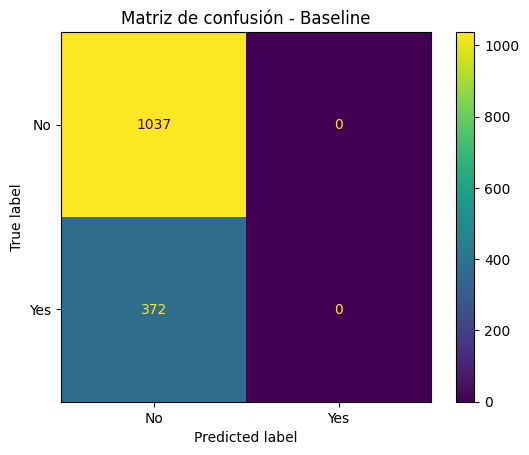


Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.74      1.00      0.85      1037
         Yes       0.00      0.00      0.00       372

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409



In [51]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Accuracy baseline: {baseline_accuracy:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    display_labels=["No", "Yes"]
)

plt.title("Matriz de confusión - Baseline")
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

### Evaluación del baseline

Aunque el modelo baseline alcanza un accuracy de aproximadamente 73,6 %,
la matriz de confusión muestra que predice todos los casos como `No`.

Como consecuencia, identifica correctamente los 1.037 casos sin Churn,
pero no detecta ninguno de los 372 casos con Churn.

El recall y el F1-score para la clase `Yes` son, por lo tanto, iguales a
cero. Esto demuestra que el accuracy por sí solo no resulta suficiente para
evaluar el desempeño del modelo en este problema y refuerza la necesidad de
comparar otras métricas.

In [43]:
from sklearn.linear_model import LogisticRegression

In [46]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [47]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [48]:
y_pred_logistic = logistic_pipeline.predict(X_test)

Accuracy Logistic Regression: 0.7949


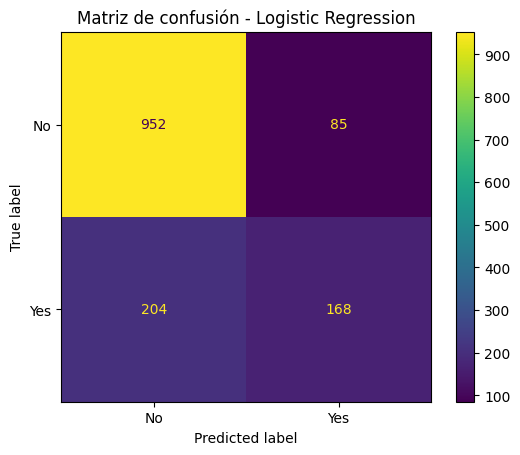


Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.82      0.92      0.87      1037
         Yes       0.66      0.45      0.54       372

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [52]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print(f"Accuracy Logistic Regression: {logistic_accuracy:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["No", "Yes"]
)

plt.title("Matriz de confusión - Logistic Regression")
plt.show()

print("\nReporte de clasificación:")
print(
    classification_report(y_test, y_pred_logistic,zero_division=0))

### Resultado de Logistic Regression

Logistic Regression obtuvo un accuracy aproximado de **0,79**, superior al
baseline de 0,736.

A diferencia del modelo baseline, Logistic Regression logra identificar
casos de Churn. Para la clase `Yes` obtuvo una precision de **0,66**, un
recall de **0,45** y un F1-score de **0,54**.

Esto indica que el modelo detecta aproximadamente el 45 % de los clientes
que efectivamente presentan Churn, aunque todavía existen casos positivos
que no logra identificar.

En comparación con el baseline, Logistic Regression presenta una capacidad
predictiva considerablemente mayor para la clase de interés.

---


### Random Forest

Como segundo modelo predictivo se utilizará `RandomForestClassifier`.

Se mantendrá el mismo conjunto de entrenamiento y prueba y el mismo
preprocesamiento utilizado anteriormente, permitiendo comparar los
resultados obtenidos con el baseline y Logistic Regression.

In [53]:
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [54]:
forest_pipeline.fit(X_train, y_train)

y_pred_forest = forest_pipeline.predict(X_test)

Accuracy Random Forest: 0.7814


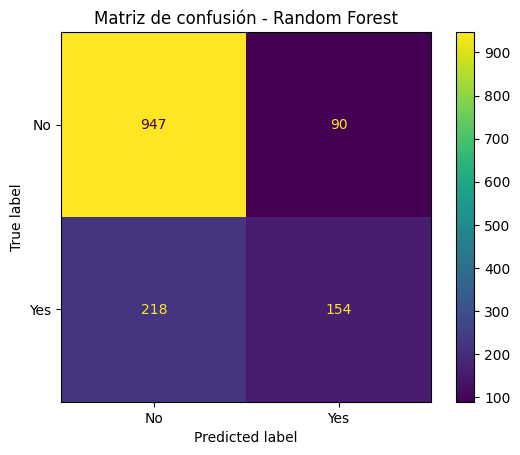


Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.81      0.91      0.86      1037
         Yes       0.63      0.41      0.50       372

    accuracy                           0.78      1409
   macro avg       0.72      0.66      0.68      1409
weighted avg       0.76      0.78      0.77      1409



In [55]:
forest_accuracy = accuracy_score(y_test, y_pred_forest)

print(f"Accuracy Random Forest: {forest_accuracy:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest,
    display_labels=["No", "Yes"]
)

plt.title("Matriz de confusión - Random Forest")
plt.show()

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred_forest,
        zero_division=0
    )
)

### Resultado de Random Forest

Random Forest obtuvo un accuracy aproximado de **0,78**.

Para la clase `Yes`, el modelo obtuvo una precision de **0,63**, un recall
de **0,41** y un F1-score de **0,50**.

El modelo logra detectar casos de Churn y supera claramente al baseline en
este aspecto. Sin embargo, con la configuración utilizada, sus métricas son
ligeramente inferiores a las obtenidas mediante Logistic Regression.

Estos resultados muestran que un modelo de mayor complejidad no implica
necesariamente un mejor desempeño predictivo.

In [58]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [59]:
results = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_forest)
    ],
    "Precision (Yes)": [
        precision_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        precision_score(y_test, y_pred_logistic, pos_label="Yes", zero_division=0),
        precision_score(y_test, y_pred_forest, pos_label="Yes", zero_division=0)
    ],
    "Recall (Yes)": [
        recall_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        recall_score(y_test, y_pred_logistic, pos_label="Yes", zero_division=0),
        recall_score(y_test, y_pred_forest, pos_label="Yes", zero_division=0)
    ],
    "F1 (Yes)": [
        f1_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        f1_score(y_test, y_pred_logistic, pos_label="Yes", zero_division=0),
        f1_score(y_test, y_pred_forest, pos_label="Yes", zero_division=0)
    ]
})

results.round(3)

,Modelo,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes)
0,Baseline,0.736,0.000,0.000,0.000
1,Logistic Regression,0.795,0.664,0.452,0.538
2,Random Forest,0.781,0.631,0.414,0.500


### Comparación de modelos

Los modelos fueron evaluados utilizando el mismo conjunto de prueba y las
mismas etapas de preprocesamiento.

El modelo baseline obtuvo un accuracy de 0,736, pero fue incapaz de detectar
casos de Churn, obteniendo recall y F1-score iguales a cero para la clase
`Yes`.

Tanto Logistic Regression como Random Forest lograron identificar casos de
Churn y superaron al baseline en este aspecto.

En esta comparación, Logistic Regression obtuvo los valores más altos entre
los modelos evaluados, con un accuracy de 0,795, precision de 0,664, recall
de 0,452 y F1-score de 0,538 para la clase `Yes`.

Random Forest obtuvo un desempeño ligeramente inferior con la configuración
utilizada.

Estos resultados corresponden al experimento realizado y no implican que un
tipo de modelo sea siempre superior al otro.

---


## 5. Conclusiones

El análisis exploratorio permitió identificar algunas relaciones entre las
variables del dataset y la variable objetivo `Churn`.

Se observó una mayor proporción de Churn entre clientes con contratos
mes a mes, menor antigüedad, servicio de fibra óptica y cargos mensuales
más elevados.

Para el modelado se realizó una división estratificada entre entrenamiento
y prueba y se utilizó un pipeline de preprocesamiento para tratar las
variables numéricas y categóricas.

Se compararon tres modelos: un baseline, Logistic Regression y Random Forest.
En este experimento, Logistic Regression obtuvo los mejores resultados entre
los modelos evaluados, alcanzando un accuracy de 0,795 y un F1-score de
0,538 para la clase `Yes`.

Como siguiente etapa, el proceso desarrollado en el notebook se trasladará
a código modular y reproducible.